In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASET/Big Mart Sales.csv")

df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          5681 non-null   object 
 1   Weight             4705 non-null   float64
 2   FatContent         5681 non-null   object 
 3   ProductVisibility  5681 non-null   float64
 4   ProductType        5681 non-null   object 
 5   MRP                5681 non-null   float64
 6   OutletID           5681 non-null   object 
 7   EstablishmentYear  5681 non-null   int64  
 8   OutletSize         4075 non-null   object 
 9   LocationType       5681 non-null   object 
 10  OutletType         5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [8]:
df.shape

(5681, 11)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,4705.0,12.695633,4.664849,4.555,8.645000,12.500000,16.700000,21.350000
ProductVisibility,5681.0,0.065684,0.051252,0.000,0.027047,0.054154,0.093463,0.323637
MRP,5681.0,141.023273,61.809091,31.990,94.412000,141.415400,186.026600,266.588400
EstablishmentYear,5681.0,1997.828903,8.372256,1985.000,1987.000000,1999.000000,2004.000000,2009.000000


In [11]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
ProductID,0
Weight,0
FatContent,0
ProductVisibility,0
ProductType,0
MRP,0
OutletID,0
EstablishmentYear,0
OutletSize,0
LocationType,0


In [18]:
X = df.drop("OutletType", axis=1)

y = df["OutletType"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
for col in X.columns:

    if X[col].dtype == 'object':

        le = LabelEncoder()

        X[col] = le.fit_transform(X[col].astype(str))

In [31]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [33]:
y_pred = knn.predict(X_test)

In [34]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix :")
print(cm)



# Classification Report

print("Classification Report :")
print(classification_report(y_test, y_pred))



Accuracy : 1.0
Confusion Matrix :
[[504   0]
 [  0 116]]
Classification Report :
                   precision    recall  f1-score   support

Supermarket Type1       1.00      1.00      1.00       504
Supermarket Type2       1.00      1.00      1.00       116

         accuracy                           1.00       620
        macro avg       1.00      1.00      1.00       620
     weighted avg       1.00      1.00      1.00       620



In [35]:

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print("K =", k, "Accuracy =", acc)

K = 1 Accuracy = 0.9967741935483871
K = 2 Accuracy = 0.9967741935483871
K = 3 Accuracy = 0.9983870967741936
K = 4 Accuracy = 0.9983870967741936
K = 5 Accuracy = 1.0
K = 6 Accuracy = 1.0
K = 7 Accuracy = 1.0
K = 8 Accuracy = 1.0
K = 9 Accuracy = 1.0
K = 10 Accuracy = 1.0


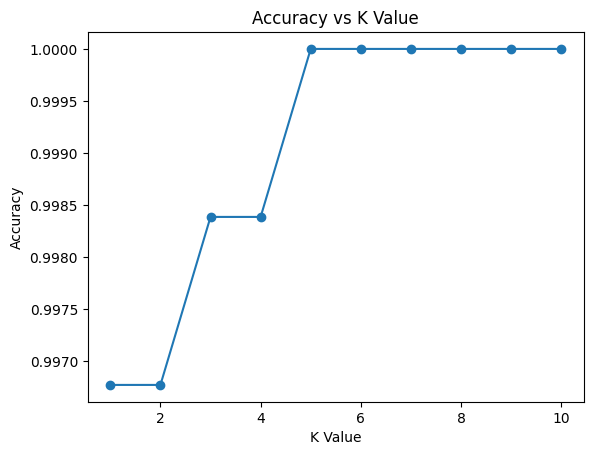

In [36]:
k_values = []
accuracies = []

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    k_values.append(k)
    accuracies.append(acc)


plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")
plt.show()